In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from torch.nn import functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from domain_shift.core.config import settings
from domain_shift.CycleGAN.triplet_data_loader import get_data_loader
from domain_shift.CycleGAN.triplet_models import CycleGAN
from domain_shift.data_extraction.process_DRIAMS import DRIAMS_bin_to_df

/home/dive001/Documents/Master/maldi-tof-domain-shift/.venv/lib/python3.11/site-packages/pydantic_settings/main.py:167: UserWarning: A custom validator is returning a value other than `self`.
Returning anything other than `self` from a top level model validator isn't supported when validating via `__init__`.
See the `model_validator` docs (https://docs.pydantic.dev/latest/concepts/validators/#model-validators) for more details.
  super().__init__(


In [2]:
# Load the data
driams_1 = DRIAMS_bin_to_df(settings.DRIAMS_C_PATH)
driams_2 = DRIAMS_bin_to_df(settings.DRIAMS_D_PATH)

In [3]:
# Combine the 'species' columns from both datasets
combined_species = pd.concat([driams_1['species'], driams_2['species']])

# Find the most represented species across both datasets
species_counts = combined_species.value_counts()
top_species = species_counts.index[:2]
top_species = top_species.tolist()
top_species

['Escherichia coli', 'Staphylococcus aureus']

In [4]:
# Show the distribution of the most represented species in each dataset
driams_1['species'].value_counts()[top_species], \
driams_2['species'].value_counts()[top_species]

(species
 Escherichia coli         927
 Staphylococcus aureus    738
 Name: count, dtype: int64,
 species
 Escherichia coli         2013
 Staphylococcus aureus    2174
 Name: count, dtype: int64)

In [5]:
# Filter by the 4 species with most representation
filtered_driams_1 = driams_1[driams_1["species"].isin(top_species)]
filtered_driams_2 = driams_2[driams_2["species"].isin(top_species)]

In [6]:
# Split into training and testing sets
driams_1_train, driams_1_val= train_test_split(filtered_driams_1, test_size=0.2, random_state=42, stratify=filtered_driams_1["species"])
driams_2_train, driams_2_val = train_test_split(filtered_driams_2, test_size=0.2, random_state=42, stratify=filtered_driams_2["species"])
len(driams_1_train), len(driams_1_val), len(driams_2_train), len(driams_2_val)

(1332, 333, 3349, 838)

In [7]:
# Get the data loaders
driams_1_train_data_loader = get_data_loader(driams_1_train)
driams_2_train_data_loader = get_data_loader(driams_2_train)
driams_1_val_data_loader = get_data_loader(driams_1_val)
driams_2_val_data_loader = get_data_loader(driams_2_val)

print("DataLoader 1 train length:", len(driams_1_train_data_loader))
print("DataLoader 2 train length:", len(driams_2_train_data_loader))

DataLoader 1 train length: 1332
DataLoader 2 train length: 3349


In [8]:
# Train the CycleGAN
cycle_gan = CycleGAN()
cycle_gan.train(driams_1_train_data_loader, driams_2_train_data_loader, driams_1_val_data_loader, driams_2_val_data_loader)

Epoch 1/50, Loss G: 1.0203, Loss D1: 0.0041, Loss D2: 0.0008, Avg GAN: 0.0060, Avg Cycle: 0.0303, Avg Identity: 0.0318, Triplet: 2.1586
Epoch 2/50, Loss G: 1.0919, Loss D1: 0.0002, Loss D2: 0.0001, Avg GAN: 0.0034, Avg Cycle: 0.0005, Avg Identity: 0.0007, Triplet: 1.7413
Epoch 3/50, Loss G: 1.1096, Loss D1: 0.0003, Loss D2: 0.0000, Avg GAN: 0.0023, Avg Cycle: 0.0004, Avg Identity: 0.0005, Triplet: 1.7181
Epoch 4/50, Loss G: 0.7333, Loss D1: 0.0041, Loss D2: 0.0000, Avg GAN: 0.0005, Avg Cycle: 0.0004, Avg Identity: 0.0005, Triplet: 1.6752
Epoch 5/50, Loss G: 0.7344, Loss D1: 0.0001, Loss D2: 0.0004, Avg GAN: 0.0007, Avg Cycle: 0.0003, Avg Identity: 0.0004, Triplet: 1.6658
Epoch 6/50, Loss G: 1.1025, Loss D1: 0.0002, Loss D2: 0.0000, Avg GAN: 0.0010, Avg Cycle: 0.0003, Avg Identity: 0.0004, Triplet: 1.6462
Epoch 7/50, Loss G: 1.0699, Loss D1: 0.0002, Loss D2: 0.0000, Avg GAN: 0.0009, Avg Cycle: 0.0003, Avg Identity: 0.0004, Triplet: 1.6204
Epoch 8/50, Loss G: 1.0603, Loss D1: 0.0007, Los

In [9]:
# Calculate min and max values
gan_min, gan_max = min(cycle_gan.gan_error_loss), max(cycle_gan.gan_error_loss)
cycle_min, cycle_max = min(cycle_gan.cycle_error_loss), max(cycle_gan.cycle_error_loss)
triplet_min, triplet_max = min(cycle_gan.triplet_error_loss), max(cycle_gan.triplet_error_loss)

# Print min and max values
print(f"GAN Error Loss: Min = {gan_min}, Max = {gan_max}")
print(f"Cycle Error Loss: Min = {cycle_min}, Max = {cycle_max}")
print(f"Triplet Error Loss: Min = {triplet_min}, Max = {triplet_max}")

GAN Error Loss: Min = 3.641410670532552e-05, Max = 0.006043420659975939
Cycle Error Loss: Min = 0.004800891881812047, Max = 1.5155674317231917
Triplet Error Loss: Min = 0.7469825752683588, Max = 1.0793219161731702


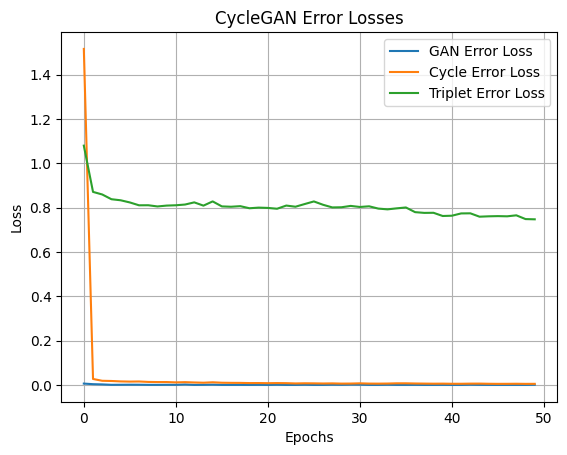

In [10]:
# Graph cycle_gan.identity_error_loss, cycle_gan.gan_error_loss, cycle_gan.cycle_error_loss
plt.plot(cycle_gan.gan_error_loss, label='GAN Error Loss')
plt.plot([error for error in cycle_gan.cycle_error_loss], label='Cycle Error Loss')
plt.plot([error for error in cycle_gan.triplet_error_loss], label='Triplet Error Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CycleGAN Error Losses')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Train Random Forest on DRIAMS 1
X = np.vstack(filtered_driams_1["binned_6000"].values)
y = filtered_driams_1["species"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

f1_score(y_test, y_pred, average='weighted')

1.0

In [12]:
# Test the model on the filtered driams 2
X = np.vstack(filtered_driams_2["binned_6000"].values)
y = filtered_driams_2["species"].values

y_pred = rf.predict(X)

f1_score(y, y_pred, average='weighted')

0.8582481947764672

In [13]:
driams_2_data_loader = get_data_loader(driams_2_train)

# Generate the synthetic data
synthetic_driams_2 = []
for data_anchor, data_positive, data_negative in driams_2_data_loader:
    output = cycle_gan.generator_2_to_1(data_anchor.to("cuda")).cpu().detach()
    synthetic_driams_2.extend(output.cpu().detach().flatten(1))
synthetic_driams_2 = torch.stack(synthetic_driams_2)

# Test the model on the synthetic driams 2
X = np.vstack(synthetic_driams_2.numpy())
y = driams_2_train["species"].values

y_pred = rf.predict(X)

f1_score(y, y_pred, average='weighted')

0.48253041606210056

In [14]:
# Train PCA on the first dataset
X = np.vstack(filtered_driams_1["binned_6000"].values)
y = filtered_driams_1["species"].values

pca = PCA(n_components=3)
pca.fit(X)
pca_driams_1 = pca.transform(X)

In [15]:
# Test the model on the original driams 2
X = np.vstack(driams_2_train["binned_6000"].values)
y = driams_2_train["species"].values

# Transform the data using the PCA trained on the first dataset
pca_driams_2 = pca.transform(X)

In [16]:
# Test the model on the synthetic driams 2
X = np.vstack(synthetic_driams_2.numpy())
y = filtered_driams_2["species"].values

# Transform the data using the PCA trained on the first dataset
transformed_pca_driams_2 = pca.transform(X)

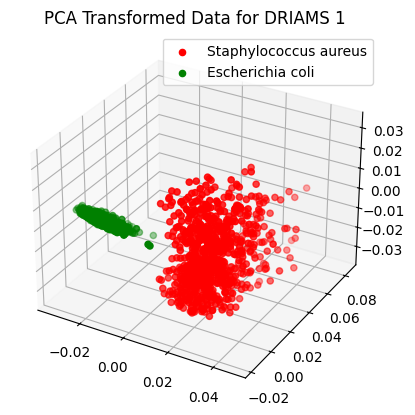

In [17]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue', 'black', 'purple']

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species
    )

ax.legend()
ax.set_title("PCA Transformed Data for DRIAMS 1")
plt.show()


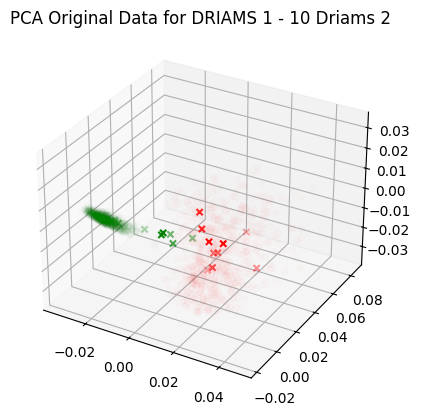

In [18]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        alpha=0.01  # Set opacity to 50%
    )

    # Add 10 synthetic samples for each species
    mask = driams_2_train["species"] == species
    plot_data = pca_driams_2[mask][:10]
    
    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        marker='x'
    )

ax.set_title("PCA Original Data for DRIAMS 1 - 10 Driams 2")
plt.show()

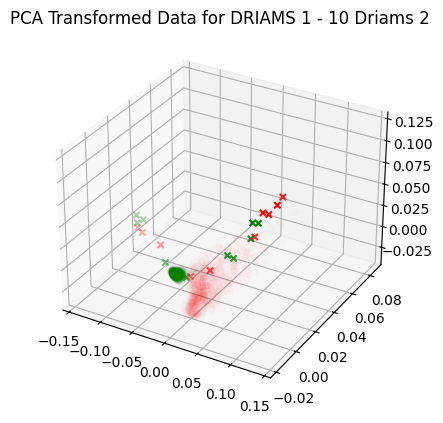

In [19]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        alpha=0.01  # Set opacity to 50%
    )

    # Add 10 synthetic samples for each species
    mask = driams_2_train["species"] == species
    plot_data = transformed_pca_driams_2[mask][:10]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        marker='x'
    )

ax.set_title("PCA Transformed Data for DRIAMS 1 - 10 Driams 2")
plt.show()